Module to run the diffusion model (using Wavestitch)

In [1]:
"""import cell"""

import os
import sys
from timeit import default_timer as timer

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import torch
from torch import nn, optim, sqrt, from_numpy, device, normal,  randint, save
from torch.utils.data import DataLoader, TensorDataset, random_split

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

sys.path.append("..")

import autoencoder as ae
from data_utils import Preprocessor
from training_utils import MyDataset, fetchDiffusionConfig, fetchModel
from utils import DimensionalityEstimator, Losses, get_frechet_distance

import fouad_wavestitch.training_and_saving_models as model_trainer


Using device: cuda
CUDA extension for cauchy multiplication not found. Install by going to extensions/cauchy/ and running `python setup.py install`. This should speed up end-to-end training by 10-50%


In [2]:
"""get diffusion config params + set dataset"""

from fouad_wavestitch.param_extractor import dataset_name, ae_args, diffusion_args, LDM_args


In [3]:
"""OLD Wavestitch"""

# np.random.seed(42)
# torch.manual_seed(42)
# parser = argparse.ArgumentParser()
# parser.add_argument('-dataset', '-d', type=str,
#                     help='MetroTraffic, BeijingAirQuality, AustraliaTourism, RossmanSales, PanamaEnergy', required=True)
# parser.add_argument('-backbone', type=str, help='Transformer, Bilinear, Linear, S4', default='S4')
# parser.add_argument('-beta_0', type=float, default=0.0001, help='initial variance schedule')
# parser.add_argument('-beta_T', type=float, default=0.02, help='last variance schedule')
# parser.add_argument('-timesteps', '-T', type=int, default=200, help='training/inference timesteps')
# parser.add_argument('-hdim', type=int, default=64, help='hidden embedding dimension')
# parser.add_argument('-lr', type=float, default=1e-4, help='learning rate')
# parser.add_argument('-batch_size', type=int, help='batch size', default=1024)
# parser.add_argument('-epochs', type=int, default=1000, help='training epochs')
# parser.add_argument('-layers', type=int, default=4, help='number of hidden layers')
# parser.add_argument('-window_size', type=int, default=32, help='the size of the training windows')
# parser.add_argument('-stride', type=int, default=1, help='the stride length to shift the training window by')
# parser.add_argument('-num_res_layers', type=int, default=4, help='the number of residual layers')
# parser.add_argument('-res_channels', type=int, default=64, help='the number of res channels')
# parser.add_argument('-skip_channels', type=int, default=64, help='the number of skip channels')
# parser.add_argument('-diff_step_embed_in', type=int, default=32, help='input embedding size diffusion')
# parser.add_argument('-diff_step_embed_mid', type=int, default=64, help='middle embedding size diffusion')
# parser.add_argument('-diff_step_embed_out', type=int, default=64, help='output embedding size diffusion')
# parser.add_argument('-s4_lmax', type=int, default=100)
# parser.add_argument('-s4_dstate', type=int, default=64)
# parser.add_argument('-s4_dropout', type=float, default=0.0)
# parser.add_argument('-s4_bidirectional', type=bool, default=True)
# parser.add_argument('-s4_layernorm', type=bool, default=True)
# parser.add_argument('-propCycEnc', type=bool, default=False)
# args = parser.parse_args()
# dataset = args.dataset
# device = device('cuda' if torch.cuda.is_available() else 'cpu')
# preprocessor = Preprocessor(dataset, args.propCycEnc)
# df = preprocessor.df_cleaned
# training_df = df.loc[preprocessor.train_indices]
# test_df = df.loc[preprocessor.test_indices]
# hierarchical_column_indices = training_df.columns.get_indexer(preprocessor.hierarchical_features_cyclic)
# # training_samples = []
# d_vals_tensor = from_numpy(training_df.values)
# training_samples = d_vals_tensor.unfold(0, args.window_size, 1).transpose(1, 2)
# # masks = m_vals_tensor.unfold(0, args.window_size, 1)
# # for i in range(0, len(training_df) - args.window_size + 1, args.stride):
# #     window = training_df.iloc[i:i + args.window_size].values
# #     training_samples.append(window)
# in_dim = len(training_df.columns)
# out_dim = len(training_df.columns) - len(hierarchical_column_indices)
# training_dataset = MyDataset(training_samples.float())
# model = fetchModel(in_dim, out_dim, args).to(device)
# diffusion_config = fetchDiffusionConfig(args)
# optimizer = optim.Adam(model.parameters(), lr=args.lr)
# criterion = nn.MSELoss()
# dataloader = DataLoader(training_dataset, batch_size=args.batch_size, shuffle=True)
# all_indices = np.arange(len(training_df.columns))

# # Find the indices not in the index_list
# remaining_indices = np.setdiff1d(all_indices, hierarchical_column_indices)

# # Convert to an ndarray
# non_hier_cols = np.array(remaining_indices)
# """TRAINING"""
# for epoch in range(args.epochs):
#     total_loss = 0.0
#     for batch in dataloader:
#         batch = batch.to(device)
#         timesteps = randint(diffusion_config['T'], size=(batch.shape[0],)).to(device)
#         sigmas = normal(0, 1, size=batch.shape).to(device)
#         """Forward noising"""
#         alpha_bars = diffusion_config['alpha_bars'].to(device)
#         coeff_1 = sqrt(alpha_bars[timesteps]).reshape((len(timesteps), 1, 1))
#         coeff_2 = sqrt(1 - alpha_bars[timesteps]).reshape((len(timesteps), 1, 1))
#         conditional_mask = np.ones(batch.shape)
#         conditional_mask[:, :, non_hier_cols] = 0
#         conditional_mask = from_numpy(conditional_mask).float().to(device)
#         batch_noised = (1 - conditional_mask) * (coeff_1 * batch + coeff_2 * sigmas) + conditional_mask * batch
#         batch_noised = batch_noised.to(device)
#         timesteps = timesteps.reshape((-1, 1))
#         # timesteps = timesteps.to(device)
#         sigmas_predicted = model(batch_noised, timesteps)
#         optimizer.zero_grad()
#         sigmas_permuted = sigmas[:, :, non_hier_cols].permute((0, 2, 1))
#         sigmas_permuted = sigmas_permuted.to(device)
#         loss = criterion(sigmas_predicted, sigmas_permuted)
#         loss.backward()
#         total_loss += loss
#         optimizer.step()
#     print(f'epoch: {epoch}, loss: {total_loss}')
# path = f'saved_models/{args.dataset}/'
# if args.propCycEnc:
#     filename = "model_prop.pth"
# else:
#     filename = "model.pth"
# filepath = os.path.join(path, filename)

# if not os.path.exists(path):
#     os.makedirs(path)
# torch.save(model.state_dict(), filepath)


'OLD Wavestitch'

In [4]:
"""Data preprocessing (from training_wavestitch.py)"""

np.random.seed(diffusion_args.random_seed)
torch.manual_seed(diffusion_args.random_seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Preprocessing (scales all data except for encoded features, then train-test splits it)
preprocessor= Preprocessor(dataset_name, diffusion_args.propCycEnc)
df          = preprocessor.df_cleaned
n_dim       = DimensionalityEstimator.estimate_dataset_dimensionality(df)
print(f"Dataset dimensionality: {n_dim:.2f}")

training_df = df.loc[preprocessor.train_indices]
test_df     = df.loc[preprocessor.test_indices]
hierarchical_column_indices = training_df.columns.get_indexer(preprocessor.hierarchical_features_cyclic)

X_tensor_train = torch.tensor(training_df.values, dtype=torch.float32)
train_dataset  = TensorDataset(X_tensor_train, X_tensor_train)
X_tensor_test  = torch.tensor(test_df.values, dtype=torch.float32)
test_dataset   = TensorDataset(X_tensor_test, X_tensor_test)


Dataset dimensionality: 4.01


In [5]:
print((X_tensor_train).mean())
print((X_tensor_test).mean())
print((df).mean())


tensor(0.0677)
tensor(-0.0731)
Sales        -5.088286e-17
Customers     6.542081e-17
Year_sine     1.410890e-01
Year_cos      8.158568e-02
Month_sine    1.136435e-01
Month_cos     1.564201e-02
Day_sine      2.761879e-02
Day_cos      -2.128627e-02
Store_sine    1.892664e-03
Store_cos     5.359313e-04
dtype: float64


In [6]:
"""Autoencoder training. Saves the model so no need to run this cell everytime"""

filepath, input_size = model_trainer.train_and_save_autoencoder(train_dataset, test_dataset, ae_args, dataset_name, device)
autoencoder = ae.Autoencoder(input_size, ae_args.ae_layer1_dim, ae_args.ae_layer2_dim, ae_args.ae_latent_dim, ae_args.ae_dropout_prob)
autoencoder.load_state_dict(torch.load(filepath))
autoencoder.to(device)
autoencoder.eval();


Epoch [20/100], training loss: 0.3222
Validation loss: 0.4885
Epoch [40/100], training loss: 0.3084
Validation loss: 0.4955
Epoch [60/100], training loss: 0.2921
Validation loss: 0.5060
Early stopping triggered


input_mean tensor(-0.0731)
recons mean tensor(0.0657)
MAE tensor(0.5892)


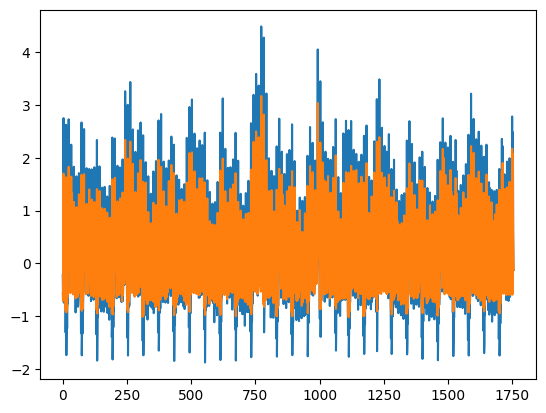

In [7]:
"""[sanity check] Apply AE latent-delatent to TEST dataset"""

loader = DataLoader(test_dataset, batch_size=ae_args.ae_batch_size, shuffle=False)

autoencoder.eval()
latents        = []
reconstructed  = []
X_input_batches= []

with torch.no_grad():
    for batch in loader:
        x_input = batch[0].to(device)
        latent  = autoencoder.encode_to_latent(x_input)
        x_output= autoencoder.decode_from_latent(latent)
        latents.append(latent.cpu())
        reconstructed.append(x_output.cpu())
        X_input_batches.append(x_input.cpu())

latents      = torch.cat(latents, dim=0)
reconstructed= torch.cat(reconstructed, dim=0)
X_input      = torch.cat(X_input_batches, dim=0)

print("input_mean", torch.mean(X_input))
print("recons mean", torch.mean(reconstructed))
MAE = Losses.compute_MAE_loss(X_input, reconstructed)
print("MAE", MAE)

variate_to_plot = 1
plt.plot(X_input[:, variate_to_plot])
plt.plot(reconstructed[:, variate_to_plot])


In [8]:
"""Training wavestitch diffusion on TRAIN set (from training_wavestitch.py). Saves the model so no need to run this cell everytime"""

# had to change S4model.py > SSKernelNPLR.register to load the model

filepath, total_loss, in_dim, out_dim = model_trainer.train_and_save_diffusion(training_df, hierarchical_column_indices, diffusion_args, dataset_name, device)

# Load model
model      = fetchModel(in_dim, out_dim, diffusion_args)
state_dict = torch.load(filepath)
state_dict = {k: v.clone() for k, v in state_dict.items()}
model.load_state_dict(state_dict)
model.to(device)
model.eval();


epoch: 10/100, total loss: 5.550034523010254
epoch: 20/100, total loss: 3.6580377221107483
epoch: 30/100, total loss: 2.173175811767578
epoch: 40/100, total loss: 1.704331487417221
epoch: 50/100, total loss: 1.5951211154460907
epoch: 60/100, total loss: 1.50089693069458
epoch: 70/100, total loss: 1.4325979799032211
epoch: 80/100, total loss: 1.3743369579315186
epoch: 90/100, total loss: 1.3117876052856445
epoch: 100/100, total loss: 1.3423517644405365


In [9]:
# # Synthesize samples using terminal version
# !python wavestitch_synthesizer.py -dataset RossmanSales -synth_mask C


In [ ]:
"""Synthesize samples on TEST set [from wavestitch_synthesizer.py]"""

from training_utils import MyDataset, fetchModel, fetchDiffusionConfig
from metasynth import metadataMask

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# --- Helper ---
def decimal_places(series):
    return series.apply(lambda x: len(str(x).split('.')[1]) if '.' in str(x) else 0).max()

# def create_pipelined_noise(test_batch, device, stride, window_size):
#     sampled = torch.normal(0, 1, (stride * (test_batch.shape[0]-1) + window_size, test_batch.shape[2])).to(device)
#     return sampled.unfold(0, window_size, stride).transpose(1, 2)

def create_pipelined_noise(batch_shape, device, window_size, stride):
    # avoid passing test_batch directly for noise creation
    total_rows = stride * (batch_shape[0]-1) + window_size
    sampled    = torch.normal(0, 1, (total_rows, batch_shape[2])).to(device)
    return sampled.unfold(0, window_size, stride).transpose(1, 2)


# --- Load Data ---
np.random.seed(diffusion_args.random_seed)
torch.manual_seed(diffusion_args.random_seed)

# preprocessor      = Preprocessor(dataset_name, diffusion_args.propCycEnc)
# df                = preprocessor.df_cleaned
end_indices       = preprocessor.test_indices[-1]
start_indices     = preprocessor.test_indices[0]
window_count      = ((end_indices + 1 - diffusion_args.window_size - start_indices) // diffusion_args.stride) + 1
tilde_start       = end_indices + 1 - diffusion_args.window_size - (window_count * diffusion_args.stride)
additional_indices= start_indices - tilde_start
# tweaking test_df to add more context to it
test_df           = df.loc[preprocessor.train_indices[-additional_indices:] + preprocessor.test_indices]
test_df_with_hierarchy = preprocessor.cyclicDecode(test_df)
decimal_accuracy  = {k: decimal_places(preprocessor.df_orig[k])
                     for k in test_df_with_hierarchy.columns}
metadata          = test_df_with_hierarchy[preprocessor.hierarchical_features_uncyclic]
rows_to_synth     = metadataMask(metadata, diffusion_args.synth_mask, dataset_name)
real_df           = test_df_with_hierarchy[rows_to_synth]
df_synth          = test_df.copy()

# --- Model Prep ---
data_tensor = from_numpy(df_synth.values)
mask_tensor = from_numpy(rows_to_synth.values)
windows     = data_tensor.unfold(0, diffusion_args.window_size, diffusion_args.stride).transpose(1, 2)
masks       = mask_tensor.unfold(0, diffusion_args.window_size, diffusion_args.stride)
hierarchical_column_indices = df_synth.columns.get_indexer(preprocessor.hierarchical_features_cyclic)

non_hier_cols   = np.setdiff1d(np.arange(len(df_synth.columns)), hierarchical_column_indices)
test_dataset    = MyDataset(windows.float())
mask_dataset    = MyDataset(masks)
model           = fetchModel(len(df_synth.columns), len(non_hier_cols), diffusion_args).to(device)
diffusion_config= fetchDiffusionConfig(diffusion_args)
test_loader     = DataLoader(test_dataset, batch_size=diffusion_args.diff_batch_size)
mask_loader     = DataLoader(mask_dataset, batch_size=diffusion_args.diff_batch_size)
model_path      = f'saved_models/{dataset_name}/model_prop.pth' if diffusion_args.propCycEnc else f'saved_models/{dataset_name}/model.pth'
saved_params    = torch.load(model_path, map_location=device)

model.load_state_dict(saved_params)
for param in model.parameters():
    param.requires_grad = False
model.eval()

real_df_out = preprocessor.rescale(real_df).reset_index(drop=True).round(decimal_accuracy)
path        = f'generated/{dataset_name}/{diffusion_args.synth_mask}/'
os.makedirs(path, exist_ok=True)
real_path   = os.path.join(path, 'real.csv')
if not os.path.exists(real_path):
    real_df_out.to_csv(real_path)

# --- Inference ---
@torch.no_grad()
def synthesize_samples(input_dataset, n_trials, device, test_loader, mask_loader, stride, window_size, hierarchical_column_indices, 
                       diffusion_config, non_hier_cols, model, rows_to_synth, preprocessor, decimal_accuracy, propCycEnc, path):
    """Wavestitch conditional synthesis, and writes to csv file for eacn trial"""
    num_ops    = 0
    exec_times = []
    for trial in range(n_trials):
        start_time   = timer()
        synth_tensor = torch.empty(0, input_dataset.inputs.shape[2]).to(device)
        for idx, (test_batch, mask_batch) in enumerate(zip(test_loader, mask_loader)):
            test_batch = test_batch.to(device)
            mask_batch = mask_batch.to(device)
            noise = create_pipelined_noise(test_batch.shape, device, window_size, stride) # Pass the SHAPE of test_batch
            x    = noise.clone()
            x[:, :, hierarchical_column_indices] = test_batch[:, :, hierarchical_column_indices]
            for step in range(diffusion_config['T'] - 1, -1, -1):
                times = torch.full((test_batch.shape[0], 1), step).to(device)
                ab_t  = diffusion_config['alpha_bars'][step].to(device)
                ab_t1 = diffusion_config['alpha_bars'][step - 1].to(device) if step > 0 else None
                at    = diffusion_config['alphas'][step].to(device)
                b_t   = diffusion_config['betas'][step].to(device)
                sampled_noise= create_pipelined_noise(test_batch.shape, device, window_size, stride) # Pass the SHAPE of test_batch
                cached       = torch.sqrt(ab_t) * test_batch + torch.sqrt(1 - ab_t) * sampled_noise
                mask_expanded= torch.zeros_like(test_batch, dtype=bool)
                for c in non_hier_cols:
                    mask_expanded[:, :, c] = mask_batch
                x[~mask_expanded] = cached[~mask_expanded]
                x[:, :, hierarchical_column_indices] = test_batch[:, :, hierarchical_column_indices]
                eps = model(x, times)
                eps = eps.permute(0, 2, 1)
                variance = 0.0
                if step > 0:
                    variance = b_t * ((1 - ab_t1) / (1 - ab_t)) * torch.normal(0, 1, size=eps.shape).to(device)
                norm_denoised= create_pipelined_noise(test_batch.shape, device, window_size, stride) # Pass the SHAPE of test_batch
                norm_denoised[:, :, non_hier_cols] = (x[:, :, non_hier_cols] - ((b_t / torch.sqrt(1 - ab_t)) * eps)) / torch.sqrt(at)
                norm_denoised[:, :, non_hier_cols] += variance
                x[mask_expanded]  = norm_denoised[mask_expanded]
                x[~mask_expanded] = test_batch[~mask_expanded]
                # we use 1: in line below and not 0: because 0 has no predecessor window to copy from
                x[1:, : (window_size - stride), :] = x.roll(1, 0)[1:, stride: window_size, :]
                if trial == 0:
                    num_ops += 1
            if idx == 0:
                generated = torch.cat((x[0], x[1:, (window_size - stride):, :].reshape(-1, x.shape[2])), dim=0)
            else:
                generated = x[:, (window_size - stride):, :].reshape(-1, x.shape[2])
            synth_tensor  = torch.cat((synth_tensor, generated), dim=0)

        exec_times.append(timer() - start_time)
        df_synthesized = pd.DataFrame(synth_tensor.cpu().numpy(), columns=df.columns)
        # synth_df_out   = preprocessor.decode(df_synthesized, rescale=True)[rows_to_synth.reset_index(drop=True)].round(decimal_accuracy)
        mask         = rows_to_synth.to_numpy() if hasattr(rows_to_synth, "to_numpy") else np.array(rows_to_synth)
        synth_df_out = preprocessor.decode(df_synthesized, rescale=True)[mask].round(decimal_accuracy)
        file_suffix  = 'cycProp' if propCycEnc else 'cycStd'
        synth_df_out.to_csv(f'{path}synth_hyacinth_pipeline_stride_{stride}_trial_{trial}_{file_suffix}.csv')
        print(f"File {trial+1}/{n_trials} done")
        if trial == 0:
            with open(f'{path}denoiser_calls_pipeline_stride_{stride}_{file_suffix}.txt', 'w') as f:
                f.write(str(num_ops))
    return synth_df_out, exec_times

synth_df_out, exec_times= synthesize_samples(test_dataset, diffusion_args.n_trials, device, test_loader, mask_loader, diffusion_args.stride, diffusion_args.window_size, hierarchical_column_indices, 
                                             diffusion_config, non_hier_cols, model, rows_to_synth, preprocessor, decimal_accuracy, diffusion_args.propCycEnc, path)

with open(f'generated/{dataset_name}/{diffusion_args.synth_mask}/denoiser_calls_pipeline_stride_{diffusion_args.stride}_cycStd.txt', 'a') as f:
    arr_time = np.array(exec_times)
    f.write('\n' + str(np.mean(arr_time)) + '\n' + str(np.std(arr_time)))


File 1/1 done


In [13]:
print(synth_df_out.mean())
# n_trial = 5
# Sales        8111.763802
# Customers     951.133751

# n_trial = 2
# Sales        7689.264087
# Customers     892.767217

# n_trial = 1
# Sales        7599.594764
# Customers     885.080250


Sales        8276.040410
Customers     688.712578
Year         2015.000000
Month           4.019351
Day            15.997723
Store           5.501992
dtype: float64


In [ ]:
# """[LDM] make latents + train them. Saves the model so no need to run this cell everytime"""
# # NOTE: SSSDS4_diffusion.py > SSSDS4Imputer class > forward() has an issue with permuting tuples
# # TODO: there is still a .permute(0, 2, 1) in forward(), which forces us to use .permute() everywhere we call the function

# # TODO: fix the below
# # Load autoencoder model
# # autoencoder = ae.Autoencoder(input_size, ae_layer1_dim, ae_layer2_dim, ae_latent_dim, ae_dropout_prob)
# # autoencoder.load_state_dict(torch.load(filepath))
# # autoencoder.to(device)
# # autoencoder.eval()

# with torch.no_grad():
#     tensor_input    = torch.tensor(training_df.values, dtype=torch.float32).to(device)
#     latent_features = autoencoder.encode_to_latent(tensor_input)
# latent_samples   = latent_features.cpu()
# latent_samples   = latent_samples.unsqueeze(-1)
# print("latent_samples:",latent_samples.shape)
# latent_dim       = latent_samples.shape[1]
# training_dataset = MyDataset(latent_samples)

# in_dim    = latent_dim
# out_dim   = latent_dim #- len(hierarchical_column_indices)  # if still masking hierarchicals in latent
# LDM_model = fetchModel(in_dim, out_dim, LDM_args).to(device)

# diffusion_config = fetchDiffusionConfig(LDM_args)
# # Move all tensors in diffusion_config to the correct device
# for k, v in diffusion_config.items():
#     if isinstance(v, torch.Tensor):
#         diffusion_config[k] = v.to(device)

# optimizer  = optim.AdamW(LDM_model.parameters(), lr=LDM_args.latent_lr)
# criterion  = nn.MSELoss()
# dataloader = DataLoader(training_dataset, batch_size=LDM_args.latent_batch_size, shuffle=True)

# # Get non-hierarchical columns
# all_indices      = np.arange(len(training_df.columns))
# remaining_indices= np.setdiff1d(all_indices, hierarchical_column_indices)
# non_hier_cols    = np.array(remaining_indices)

# def latent_diffusion_training_loop(epochs, dataloader, device, diffusion_config, model, optimizer, criterion) -> float:
#     """Training loop of the Diffusion part of the LDM. NOTE: NO CONDITIONAL MASK for now"""
#     for epoch in range(epochs):
#         total_loss = 0.0
#         for batch in dataloader:
#             batch = batch.to(device)
#             optimizer.zero_grad()
#             t           = torch.randint(diffusion_config['T'], (batch.shape[0],), device=device).long()
#             t           = t.unsqueeze(1)
#             alpha_bars  = diffusion_config['alpha_bars'].to(device)
#             coeff_1     = torch.sqrt(alpha_bars[t]).reshape(len(t), 1, 1)
#             coeff_2     = torch.sqrt(1 - alpha_bars[t]).reshape(len(t), 1, 1)
#             sigmas      = torch.randn_like(batch, device=device)
#             batch_noised= coeff_1 * batch + coeff_2 * sigmas
#             sigmas_predicted= model(batch_noised.permute(0, 2, 1), t)
#             # If masking or channel selection needed, apply here to both sigmas_predicted and sigmas
#             loss = criterion(sigmas_predicted, sigmas)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item()
#         if (epoch + 1) % 5 == 0:
#             print(f'epoch: {epoch+1}/{epochs}, total loss: {total_loss:.4f}')
#     return total_loss

# total_loss = latent_diffusion_training_loop(LDM_args.latent_epochs, dataloader, device, diffusion_config, LDM_model, optimizer, criterion)

# # Save model
# path     = f'saved_models/{dataset}/'
# filename = "ldm_model_prop.pth" if LDM_args.propCycEnc else "latent_model.pth"
# filepath = os.path.join(path, filename)
# os.makedirs(path, exist_ok=True)
# torch.save(LDM_model.state_dict(), filepath)

# # Load LDM
# model.load_state_dict(torch.load(filepath))
# LDM_model.eval()

filepath, total_loss, in_dim, out_dim, latent_dim = model_trainer.train_and_save_ldm_model(
    training_df, autoencoder, # Pass the already loaded autoencoder
    LDM_args, dataset_name, device, hierarchical_column_indices # Pass this if it's an input to your new function
)

print(f"LDM Training complete. Best loss: {total_loss}")
print(f"LDM model saved to: {filepath}")

# --- Load LDM (keep this for immediate use after training) ---
# Re-instantiate the model structure
LDM_model = fetchModel(in_dim, out_dim, LDM_args).to(device)
# Load the saved state dictionary
LDM_model.load_state_dict(torch.load(filepath, map_location=device))
# Set to evaluation mode
LDM_model.eval()

print("LDM model loaded and ready for use.")


latent_samples: torch.Size([6063, 4, 1])
epoch: 5/100, total loss: 19.9826
epoch: 10/100, total loss: 15.9451
epoch: 15/100, total loss: 15.0168
epoch: 20/100, total loss: 14.3589
epoch: 25/100, total loss: 14.3021
epoch: 30/100, total loss: 13.6816
epoch: 35/100, total loss: 13.9567
epoch: 40/100, total loss: 14.0873
epoch: 45/100, total loss: 14.1856
epoch: 50/100, total loss: 14.1756
epoch: 55/100, total loss: 14.0880
epoch: 60/100, total loss: 13.9128
epoch: 65/100, total loss: 13.8296
epoch: 70/100, total loss: 13.5495
epoch: 75/100, total loss: 13.5688
epoch: 80/100, total loss: 13.7108
epoch: 85/100, total loss: 13.7373
epoch: 90/100, total loss: 13.7409
epoch: 95/100, total loss: 13.3624
epoch: 100/100, total loss: 13.9926
LDM Training complete. Best loss: 13.992595255374908
LDM model saved to: saved_models/RossmanSales/latent_model.pth
LDM model loaded and ready for use.


In [ ]:
z_T = torch.randn((LDM_args.num_samples, latent_dim, latent_dim), device=device)
x = z_T
LDM_model.eval()
with torch.no_grad():
    # watch out for ['T']
    for t_step in reversed(range(diffusion_config['T'])):
        t = torch.full((LDM_args.num_samples, 1), t_step, device=device, dtype=torch.long)
        eps = LDM_model(x.permute(0, 2, 1), t).permute(0, 2, 1)  # model predicts noise
        alpha_bar = diffusion_config['alpha_bars'][t_step].to(device)
        alpha     = diffusion_config['alphas'][t_step].to(device)
        beta      = diffusion_config['betas'][t_step].to(device)
        if t_step > 0:
            noise = torch.randn_like(x)
        else:
            noise = 0
        x = (1 / torch.sqrt(alpha)) * (x - (beta / torch.sqrt(1 - alpha_bar)) * eps) + torch.sqrt(beta) * noise
x = x.mean(dim=-1)

latent_repr      = x
decoded_tensor   = autoencoder.decode_from_latent(latent_repr)
decoded_np       = decoded_tensor.detach().cpu().numpy()
generated_df     = pd.DataFrame(decoded_np, columns=training_df.columns)

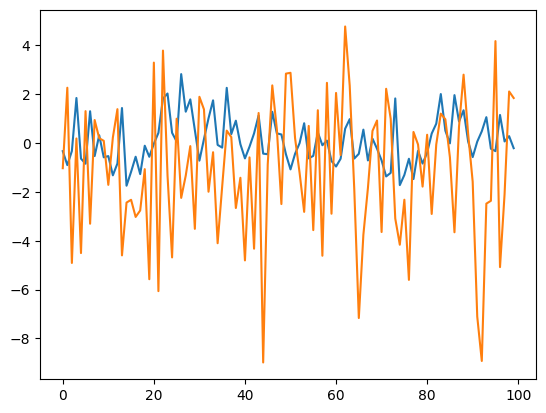

In [ ]:

# stopped here!

# print(latent_samples.mean())

variate_to_plot = 0
plt.plot(X_input[:LDM_args.num_samples, variate_to_plot])
# plt.plot(reconstructed[:, variate_to_plot])
plt.plot(generated_df.iloc[:,variate_to_plot])


tensor(0.0677)
tensor(0.0684)
tensor(0.3817)


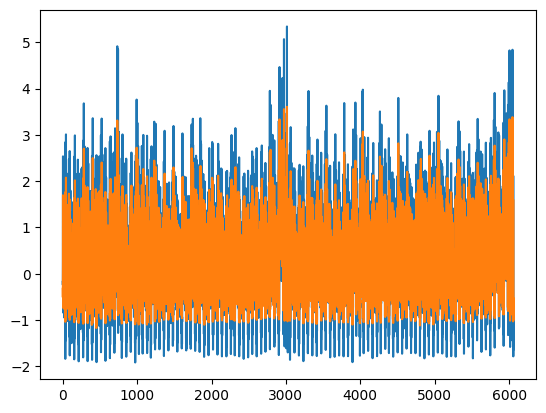

In [ ]:
"""[OLD] LDM"""

training_df_tensor = torch.tensor(training_df.values, dtype=torch.float32).to(device)
latent_features  = autoencoder.encode_to_latent(x_input)
# %%%%%%%%%%%%%%%%%%
@torch.no_grad()
def latent_synthesize_samples(input_dataset, n_trials, device, test_loader, model, autoencoder, diffusion_config):
    for trial in range(n_trials):
        synth_latent = torch.empty(0, latent_dim).to(device)
        for test_batch in test_loader:
            test_batch = test_batch.to(device)
            latent_batch = autoencoder.encode_to_latent(test_batch)
            noise = torch.normal(0, 1, latent_batch.shape).to(device)
            x = noise.clone()

            for step in reversed(range(diffusion_config['T'])):
                times = torch.full((latent_batch.shape[0], 1), step).to(device)
                # diffusion update on latent x here
                eps = model(x, times)
                # denoise x according to diffusion equation in latent space

            synth_latent = torch.cat((synth_latent, x), dim=0)

        x_output = autoencoder.decode_from_latent(synth_latent)
        # Save or return x_output as synthesized samples
    return x_output

# %%%%%%%%%%%%%%%%%

x_output= autoencoder.decode_from_latent(latent_features)


# =========================================================
ae_dataset = train_dataset #val_dataset # 
loader     = DataLoader(ae_dataset, batch_size=ae_args.ae_batch_size, shuffle=False)

autoencoder.eval()
latents        = []
reconstructed  = []
X_input_batches= []

with torch.no_grad():
    for batch in loader:
        x_input = batch[0].to(device)
        latent  = autoencoder.encode_to_latent(x_input)
        x_output= autoencoder.decode_from_latent(latent)
        latents.append(latent.cpu())
        reconstructed.append(x_output.cpu())
        X_input_batches.append(x_input.cpu())

latents      = torch.cat(latents, dim=0)
reconstructed= torch.cat(reconstructed, dim=0)
X_input      = torch.cat(X_input_batches, dim=0)

print(torch.mean(X_input))
print(torch.mean(reconstructed))
MAE = Losses.compute_MAE_loss(X_input, reconstructed)
print(MAE)

variate_to_plot = 1
plt.plot(X_input[:, variate_to_plot])
plt.plot(reconstructed[:, variate_to_plot])


<Axes: >

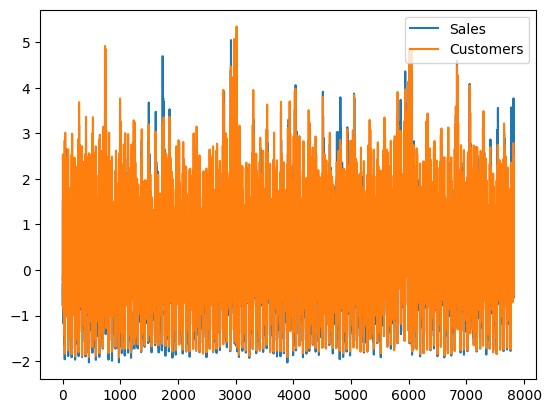

In [ ]:
df_generated = pd.read_csv(f"generated/{dataset_name}/{diffusion_args.synth_mask}/synth_hyacinth_pipeline_stride_1_trial_3_cycStd.csv")
# df_generated.iloc[:, [1,2]].plot()
df.iloc[:, [0,1]].plot()


In [ ]:
# real_df_out.head
synth_df_out.head


<bound method NDFrame.head of       Sales  Customers  Year  Month  Day  Store
1      6653        561  2015      1    2      1
2      7631        628  2015      1    2      2
3     11586        835  2015      1    2      3
4     13048       1495  2015      1    2      4
5      7669        680  2015      1    2      5
...     ...        ...   ...    ...  ...    ...
1753  10407        812  2015      7   31      6
1754  12099        866  2015      7   31      7
1755   9544        815  2015      7   31      8
1756  11373        691  2015      7   31      9
1757   9151        752  2015      7   31     10

[1757 rows x 6 columns]>

In [ ]:
"""Metrics for AE-reconstructed data quality"""

# Prepare data
X_real  = real_df_out.values.astype(np.float32)
X_synth = synth_df_out.values.astype(np.float32)

# Split + scale data
X_train, X_val= train_test_split(X_real, test_size=0.2, random_state=42)
scaler        = StandardScaler()
X_train_scaled= scaler.fit_transform(X_train)
X_val_scaled  = scaler.transform(X_val)
X_synth_scaled= scaler.transform(X_synth)

# Convert to tensors + build datasets
X_train_tensor = torch.tensor(X_train_scaled)
X_val_tensor   = torch.tensor(X_val_scaled)
X_synth_tensor = torch.tensor(X_synth_scaled, dtype=torch.float32).to(device)
train_dataset  = TensorDataset(X_train_tensor, torch.zeros(len(X_train_tensor)))
val_dataset    = TensorDataset(X_val_tensor, torch.zeros(len(X_val_tensor)))

# Training setup
device      = ae.device
input_size  = X_train_tensor.shape[1] # num of features
train_loader= DataLoader(train_dataset, batch_size=ae_args.ae_batch_size, shuffle=True)
val_loader  = DataLoader(val_dataset, batch_size=ae_args.ae_batch_size, shuffle=False)
autoencoder = ae.Autoencoder(input_size, ae_args.ae_layer1_dim, ae_args.ae_layer2_dim, ae_args.ae_latent_dim, ae_args.ae_dropout_prob).to(device)
optimizer   = torch.optim.AdamW(autoencoder.parameters(), lr=ae_args.ae_optimizer_lr, weight_decay=ae_args.ae_weight_decay)
scheduler   = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, ae_args.ae_scheduler_mode, patience=ae_args.ae_scheduler_patience, factor=ae_args.ae_scheduler_factor)

# Train AE
trainer = ae.TrainAutoencoder()
trainer.train_autoencoder(device, autoencoder, ae_args.ae_training_epochs, train_loader, optimizer, scheduler,
                          validation_loader=val_loader, patience=ae_args.ae_training_patience)

# Make latents + reconstruction (optional)
autoencoder.eval()
with torch.no_grad():
    X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32).to(device)
    real_latents = autoencoder.encode_to_latent(X_val_tensor).cpu().numpy()
    synth_latents= autoencoder.encode_to_latent(X_synth_tensor).cpu().numpy()
    # X_reconstructed = autoencoder(X_train_tensor.to(device)).cpu().numpy()

#  FID metric
FID_distance = get_frechet_distance(real_latents, synth_latents)
print(real_latents.shape)
print(synth_latents.shape)
print(FID_distance)


Epoch [20/100], training loss: 0.3994
Validation loss: 0.2561
Epoch [40/100], training loss: 0.3192
Validation loss: 0.1706
Epoch [60/100], training loss: 0.3149
Validation loss: 0.1413
Epoch [80/100], training loss: 0.2973
Validation loss: 0.1344
Epoch [100/100], training loss: 0.2798
Validation loss: 0.1203
(352, 4)
(1757, 4)
0.4665206019755296


t-SNE done.
UMAP done.


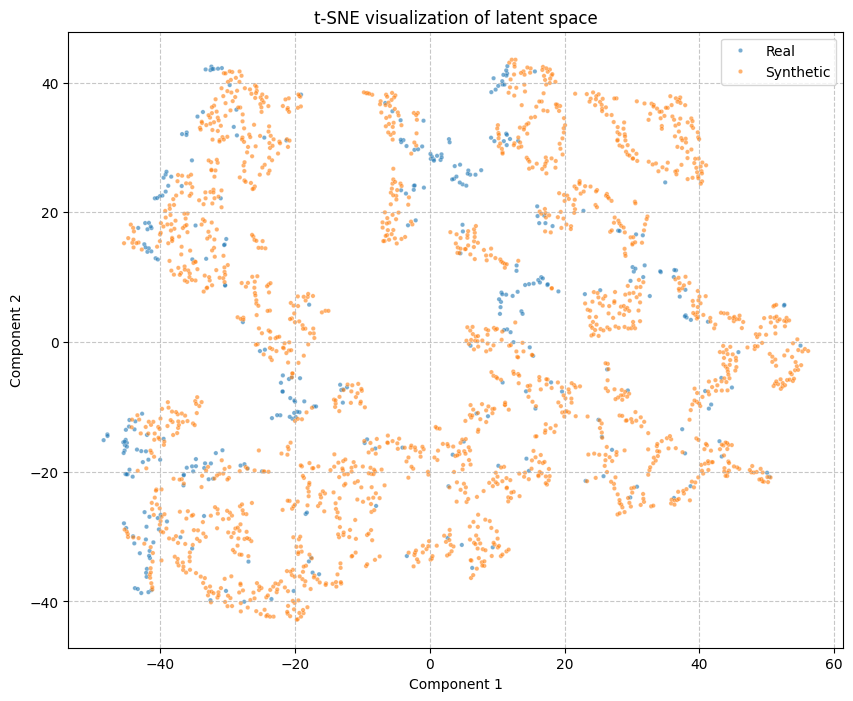

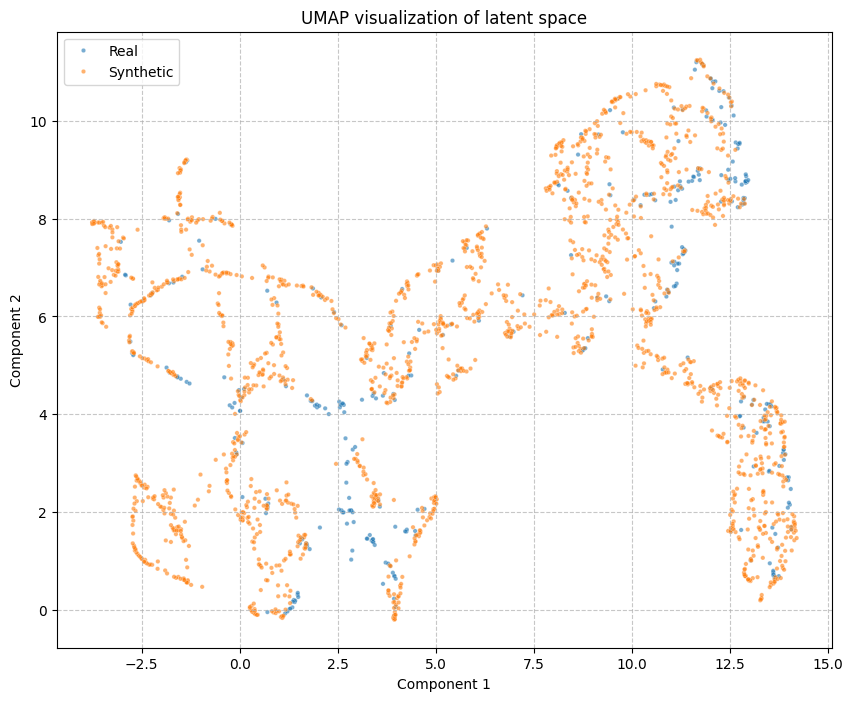

In [ ]:
"""t-SNE/UMAP"""

import seaborn as sns
from sklearn.manifold import TSNE
import umap

if isinstance(real_latents, torch.Tensor):
    real_latents = real_latents.cpu().numpy()
if isinstance(synth_latents, torch.Tensor):
    synth_latents = synth_latents.cpu().numpy()

# 1. Combine Latents and Create Labels
all_latents= np.vstack((real_latents, synth_latents))
labels     = ['Real'] * len(real_latents) + ['Synthetic'] * len(synth_latents)
labels_np  = np.array(labels) # Convert labels to np (easier indexing)

# 2. Apply t-SNE
# n_components: 2 for 2D plot, 3 for 3D plot
# perplexity: controls balance between local and global aspects of data (often 5-50)
# n_iter: number of iterations for optimization
tsne_results = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42, learning_rate='auto').fit_transform(all_latents)
print("t-SNE done.")

# 3. Apply UMAP
# n_neighbors: balances local vs. global structure (smaller for local, larger for global)
# min_dist: controls how tightly points are packed together
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
umap_results = reducer.fit_transform(all_latents)
print("UMAP done.")

# 4. Plotting
def plot_latent_space(embedding, labels, title):
    plt.figure(figsize=(10, 8))
    sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=labels,
                    palette=['#1f77b4', '#ff7f0e'], s=10, alpha=0.6, legend='full')
    plt.title(title)
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
plot_latent_space(tsne_results, labels_np, 't-SNE visualization of latent space')
plot_latent_space(umap_results, labels_np, 'UMAP visualization of latent space')

# # To make 3D plots, set n_components=3
# from mpl_toolkits.mplot3d import Axes3D
# def plot_latent_space_3d(embedding, labels, title):
#     fig = plt.figure(figsize=(10, 8))
#     ax = fig.add_subplot(111, projection='3d')
#     colors = {'Real': '#1f77b4', 'Synthetic': '#ff7f0e'}
#     for label_val in np.unique(labels):
#         idx = (labels == label_val)
#         ax.scatter(embedding[idx, 0], embedding[idx, 1], embedding[idx, 2],
#                    color=colors[label_val], label=label_val, s=10, alpha=0.6)
#     ax.set_title(title)
#     ax.set_xlabel('Component 1')
#     ax.set_ylabel('Component 2')
#     ax.set_zlabel('Component 3')
#     ax.legend()
#     plt.show()
# tsne_results_3d = TSNE(n_components=3, perplexity=30, n_iter=1000, random_state=42, learning_rate='auto').fit_transform(all_latents)
# umap_results_3d = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.1, random_state=42).fit_transform(all_latents)
# plot_latent_space_3d(tsne_results_3d, labels_np, 't-SNE 3D Visualization of Latent Space')
# plot_latent_space_3d(umap_results_3d, labels_np, 'UMAP 3D Visualization of Latent Space')
